# 00 — Brownian Movement

## Preparation

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from stage_escape import BrownianMotion
from stage_escape.visualization import plot_brownian_path

plt.rcParams.update(
    {
        "figure.figsize": (8.0, 4.8),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": False,
    }
)

SAVE_FIGURES = True

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró pyproject.toml. Ejecuta el notebook dentro del repositorio."
    )

REPO_ROOT = find_repo_root()
FIGURE_DIR = REPO_ROOT / "artifacts" / "figures" / "notebook_00"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def finish_figure(fig, name: str) -> None:
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()

## 1. Bidimensional Path

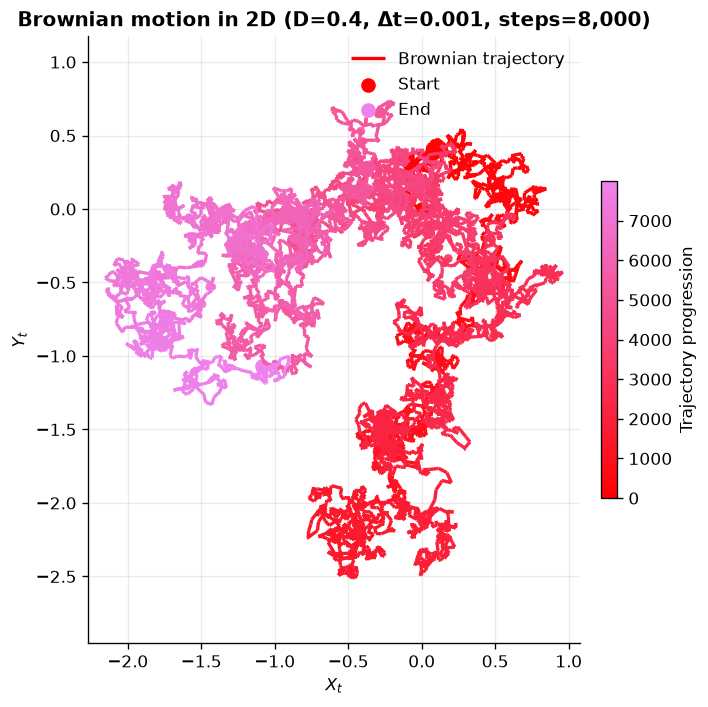

In [17]:
SEED = 2026
D = 0.40
DELTA_T = 1.0e-3
N_STEPS_2D = 8_000

motion_2d = BrownianMotion(
    deposition_stride=N_STEPS_2D + 1,
    delta_t=DELTA_T,
    dimension=2,
    D=D,
    initial_position=np.zeros(2),
    seed=SEED,
)
path_2d = motion_2d.simulate()

assert motion_2d.n_steps == N_STEPS_2D
assert path_2d.shape == (N_STEPS_2D + 1, 2)

fig, ax = plot_brownian_path(
    path_2d,
    title=(
        "Brownian motion in 2D "
        f"(D={D:g}, Δt={DELTA_T:g}, steps={N_STEPS_2D:,})"
    ),
    show_points=True,
    point_stride=400,
    point_size=28,
    point_alpha=0.9,
    show=False,
)
ax.set_xlabel(r"$X_t$")
ax.set_ylabel(r"$Y_t$")
finish_figure(fig, "brownian_path_2d")

## 2. Reproducibility

In [18]:
def simulate_path(seed: int) -> np.ndarray:
    motion = BrownianMotion(
        deposition_stride=2_001,
        delta_t=DELTA_T,
        dimension=1,
        D=D,
        initial_position=np.zeros(1),
        seed=seed,
    )
    return motion.simulate()

reference_path = simulate_path(SEED)
repeated_path = simulate_path(SEED)

np.testing.assert_array_equal(reference_path, repeated_path)
print("Reproducibilidad exacta verificada para seed =", SEED)

Reproducibilidad exacta verificada para seed = 2026


## 3. Variance Validation

For a brownian process: 

$[
X_t - X_0 \sim \mathcal{N}(0,\,2Dt),
\qquad
\operatorname{Var}(X_t)=2Dt.
]$

In [24]:
N_REPLICAS = 3000
N_STEPS_1D = 10_000
REPLICA_SEED = 10_000

trajectories = np.empty((N_REPLICAS, N_STEPS_1D + 1), dtype=float)

for replica in range(N_REPLICAS):
    motion = BrownianMotion(
        deposition_stride=N_STEPS_1D + 1,
        delta_t=DELTA_T,
        dimension=1,
        D=D,
        initial_position=np.zeros(1),
        seed=REPLICA_SEED + replica,
    )
    trajectories[replica] = motion.simulate()[:, 0]

times = np.arange(N_STEPS_1D + 1) * DELTA_T
empirical_mean = trajectories.mean(axis=0)
empirical_variance = trajectories.var(axis=0, ddof=1)
theoretical_variance = 2.0 * D * times

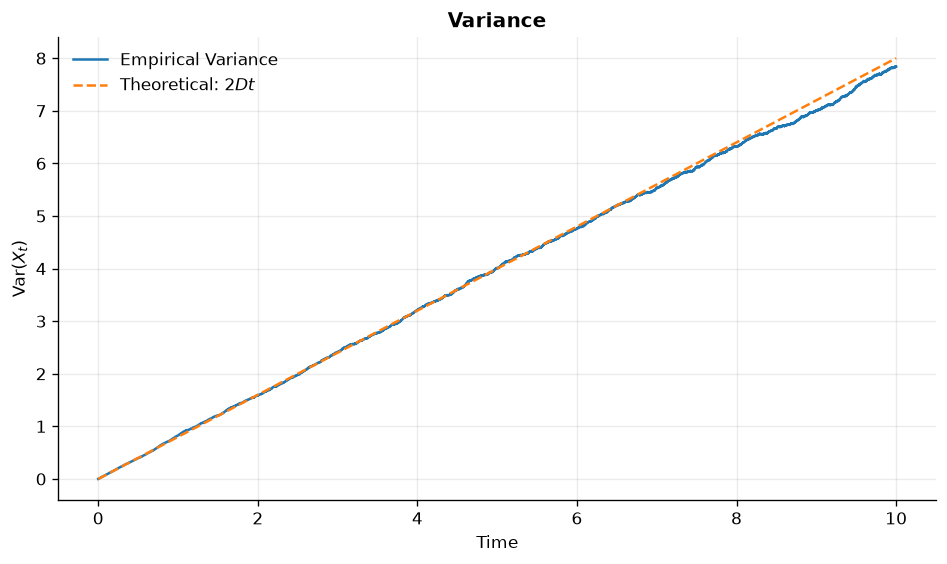

In [25]:
fig, ax = plt.subplots()
ax.plot(times, empirical_variance, label="Empirical Variance")
ax.plot(times, theoretical_variance, linestyle="--", label=r"Theoretical: $2Dt$")
ax.set(
    title="Variance",
    xlabel="Time",
    ylabel=r"$\operatorname{Var}(X_t)$",
)
ax.legend()
finish_figure(fig, "brownian_variance_validation")

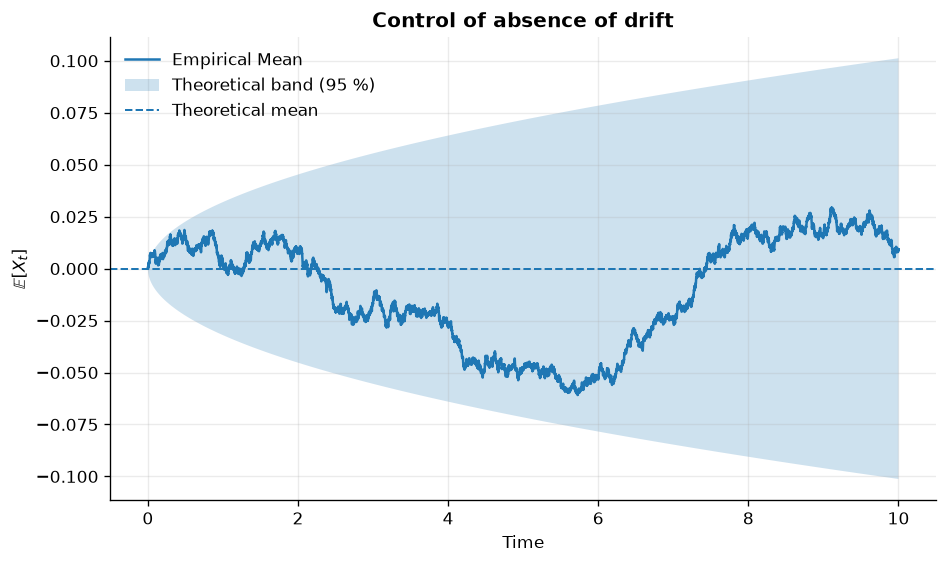

In [26]:
standard_error = np.sqrt(theoretical_variance / N_REPLICAS)
confidence_radius = 1.96 * standard_error

fig, ax = plt.subplots()
ax.plot(times, empirical_mean, label="Empirical Mean")
ax.fill_between(
    times,
    -confidence_radius,
    confidence_radius,
    alpha=0.22,
    label="Theoretical band (95 %)",
)
ax.axhline(0.0, linestyle="--", linewidth=1.2, label="Theoretical mean")
ax.set(
    title="Control of absence of drift",
    xlabel="Time",
    ylabel=r"$\mathbb{E}[X_t]$",
)
ax.legend()
finish_figure(fig, "brownian_mean_validation")

## 4. Final Distribution

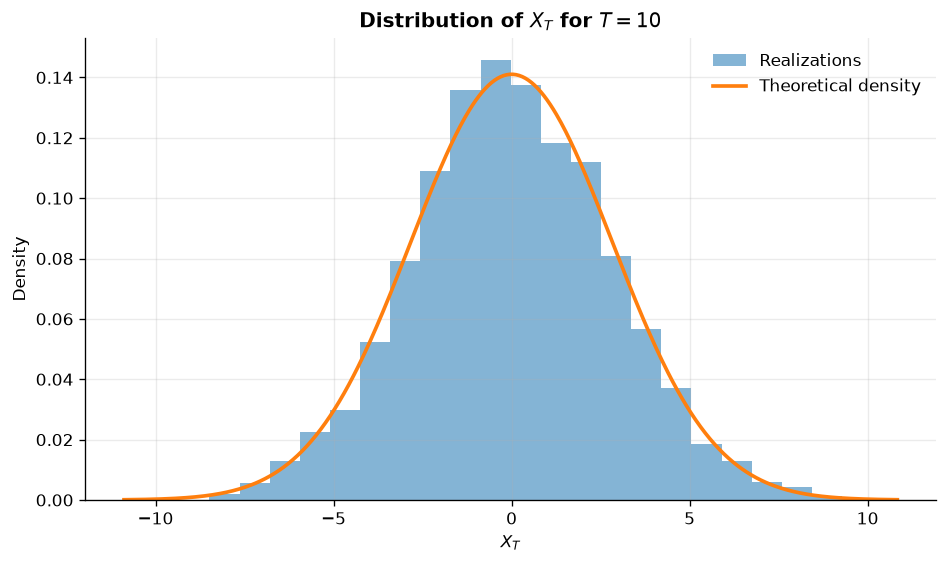

In [27]:
final_positions = trajectories[:, -1]
final_time = times[-1]
theoretical_std = np.sqrt(2.0 * D * final_time)

x_grid = np.linspace(
    final_positions.min() - 0.25 * theoretical_std,
    final_positions.max() + 0.25 * theoretical_std,
    500,
)

fig, ax = plt.subplots()
ax.hist(
    final_positions,
    bins=24,
    density=True,
    alpha=0.55,
    label="Realizations",
)
ax.plot(
    x_grid,
    norm.pdf(x_grid, loc=0.0, scale=theoretical_std),
    linewidth=2.2,
    label="Theoretical density",
)
ax.set(
    title=rf"Distribution of $X_T$ for $T={final_time:g}$",
    xlabel=r"$X_T$",
    ylabel="Density",
)
ax.legend()
finish_figure(fig, "brownian_terminal_distribution")

## 5. Indicators

In [28]:
empirical_final_variance = float(empirical_variance[-1])
theoretical_final_variance = float(theoretical_variance[-1])
relative_variance_error = abs(
    empirical_final_variance - theoretical_final_variance
) / theoretical_final_variance

summary = {
    "réplicas": N_REPLICAS,
    "pasos por réplica": N_STEPS_1D,
    "tiempo final": final_time,
    "media final empírica": float(empirical_mean[-1]),
    "varianza final empírica": empirical_final_variance,
    "varianza final teórica": theoretical_final_variance,
    "error relativo de varianza": relative_variance_error,
}

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key:31s}: {value:.6g}")
    else:
        print(f"{key:31s}: {value}")

réplicas                       : 3000
pasos por réplica              : 10000
tiempo final                   : 10
media final empírica           : 0.00925913
varianza final empírica        : 7.83966
varianza final teórica         : 8
error relativo de varianza     : 0.0200425
